# Logistic Regression
Partiamo dalla Logistic Regression con soft max. 
Pensiamo il problema posto come il seguente: "posso prevedere come sarà l'indice di qualità dell'aria tra un'ora attorno ad una data stazione, usando informazioni dell'arpav e dell'appa per le ore a questa precedenti?"

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets


from  sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

import sys
sys.path.append('../..')

import src.class_funcs as fs

In [142]:
# prepariamo il dataframe per questo studio (poi questa parte va probabilmente spostata)
dataset_df = pd.read_csv('../../data/processed/dataset_EDA_processed.csv')
# voglio trasformare la data in un numero da 1 al massimo
dataset_df["date"] = pd.to_datetime(dataset_df["date"])
dataset_df["day"] = (dataset_df["date"] - dataset_df["date"].min()).dt.days + 1
dataset_df = dataset_df.drop(columns='date')

# cambiamo i giorni della settimana nel nome dei giorni
dataset_df["week_day"] = dataset_df["week_day"].astype(str)
day = {'0':'lunedì', '1':'martedì', '2':'mercoledì', '3':'giovedì', '4':'venerdì', '5':'sabato', '6':'domenica'}
dataset_df['week_day'] = dataset_df['week_day'].map(day)

# inseriamo l'AQI e togliamo le colonne di inquinanti non misurate da tutte le stazioni
inq_intervals = {'PM2.5':[(0, 10), (10, 20), (20, 25), (25, 30), (30, np.inf)], 
            'PM10':[(0, 20), (20, 35), (35, 50), (50, 100), (100, np.inf)],
            'NO2':[(0, 40), (40, 100), (100, 200), (200, 400), (400, np.inf)],
            'O3':[(0, 80), (80, 120), (120, 180), (180, 240), (240, np.inf)],
            'SO2':[(0, 100), (100, 200), (200, 350), (350, 500), (500, np.inf)],
            'CO':[(0, 5), (5, 7.5), (7.5, 10), (10, 20), (20, np.inf)]}

for inq in inq_intervals.keys():
    dataset_df['AQI_' + inq] = dataset_df[inq].apply(lambda x: fs.get_AQI_inq(x, inq_intervals[inq]))

AQI_cols = ['AQI_' + inq for inq in inq_intervals.keys()]

dataset_df['AQI'] = dataset_df[AQI_cols].max(axis=1)
dataset_df = dataset_df.drop(columns=AQI_cols)
# devo togliere i nan => tolgo tutte le colonne di inquinanti che non sono misurati da tutte le stazioni (rimangono solo PM10 e NO2)
# se necessario, stiamo già tenendo conto del contributo degli altri inquinanti nell'AQI 
dataset_df = dataset_df.drop(columns=['CO', 'O3', 'PM2.5', 'SO2'])

# tengo solo le colonne che mi interessano
feature_cols = ['station_appa', 'day', 'hour', 'week_day', 'elevation', 'PM10', 'NO2', 'AQI', 'tot_area_power', 'temperature', 'precipitation']
dataset_df = dataset_df[feature_cols + ['EAQI']]

target = dataset_df['EAQI']

dataset_df.head()

,station_appa,day,hour,week_day,elevation,PM10,NO2,AQI,tot_area_power,temperature,precipitation,EAQI
0,Borgo Valsugana,1,23,venerdì,410,25.0,16.0,32.5,921.457256,10.0,0.0,fair
1,Borgo Valsugana,2,1,sabato,410,25.0,14.0,37.5,938.390584,10.1,0.0,fair
2,Borgo Valsugana,2,2,sabato,410,25.0,15.0,37.5,940.862870,10.0,0.0,fair
3,Borgo Valsugana,2,3,sabato,410,25.0,12.0,40.0,943.581445,10.2,0.0,fair
4,Borgo Valsugana,2,4,sabato,410,23.0,12.0,40.0,941.596837,10.0,0.0,fair


In [143]:
# vogliamo prevedere l'EAQI ad un'ora date le informazioni sulle ore precedenti
# per evitare di appesantire troppo il dataframe consideriamo solo le tre ore precedenti per tutti i dati eccetto le precipitazioni
# abbiamo visto una correlasione particolare per gli inquinanti con le precipitazioni dalle 5 ore prima in poi. Per questo dato prendiamo quindi le precipitazioni
# di 5, 6 e 7 ore prima (invece che delle tre ore appena precedenti)

feature_df = dataset_df[feature_cols[:5]].copy()
for h in range (1,4):
    feature_df[[col + f'_{h}' for col in feature_cols[5:10]]] = dataset_df.groupby('station_appa')[feature_cols[5:10]].shift(h)
    feature_df[f'precipitation_{4 + h}'] = dataset_df.groupby('station_appa')[feature_cols[-1]].shift(5 + h)

# trasformiamo in one-hot le stazioni ed il giorno della settimana
feature_df = pd.get_dummies(feature_df, columns=['week_day'], prefix='', prefix_sep='')
feature_df = pd.get_dummies(feature_df, columns=['station_appa'], prefix='', prefix_sep='')

classification_df = feature_df.copy()
classification_df['target'] = target
classification_df = classification_df.dropna(subset=['precipitation_7'])

classification_features = classification_df.columns.difference(['target'])

classification_df.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,fair
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,fair
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,fair
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,fair
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,fair


In [144]:
# vediamo se ci sono righe con nan e togliamole
classification_df = classification_df[~classification_df.isna().any(axis=1)]
classification_df.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano,target
8,2,8,410,23.0,16.0,25.000000,927.923195,9.6,0.0,23.0,...,False,False,True,False,True,False,False,False,False,fair
9,2,9,410,24.0,21.0,26.666667,921.967223,9.9,0.0,23.0,...,False,False,True,False,True,False,False,False,False,fair
10,2,10,410,29.0,19.0,35.000000,916.103636,10.3,0.0,24.0,...,False,False,True,False,True,False,False,False,False,fair
11,2,11,410,29.0,23.0,35.000000,913.024411,11.0,0.0,29.0,...,False,False,True,False,True,False,False,False,False,fair
12,2,12,410,27.0,23.0,31.666667,909.916536,11.4,0.4,29.0,...,False,False,True,False,True,False,False,False,False,fair


In [145]:
# creo train, valid e test
train, test = train_test_split(classification_df, test_size=0.20, random_state=12)
non_num_cols = ['day', 'hour', 'lunedì', 'martedì', 'mercoledì', 'giovedì', 'venerdì', 'sabato', 'domenica', 'Borgo Valsugana', 'Monte Gaza', 'Parco S. Chiara', 
                'Rovereto', 'Via Bolzano', 'target']
num_features = train.columns.difference(non_num_cols)

scaler = StandardScaler()
scaled_num_train = scaler.fit_transform(train[num_features])
scaled_num_test = scaler.transform(test[num_features])

scaled_train = train.copy()
scaled_test = test.copy()

scaled_train[num_features] = scaled_num_train
scaled_test[num_features] = scaled_num_test

# tolgo il target dal dataframe con le features

scaled_train = scaled_train.drop(columns='target')
scaled_test = scaled_test.drop(columns='target')

scaled_train.head()

,day,hour,elevation,PM10_1,NO2_1,AQI_1,tot_area_power_1,temperature_1,precipitation_5,PM10_2,...,lunedì,martedì,mercoledì,sabato,venerdì,Borgo Valsugana,Monte Gaza,Parco S. Chiara,Rovereto,Via Bolzano
4481,20,19,-0.902186,-0.668280,0.531191,-0.494027,0.261968,0.884977,-0.207548,-0.624365,...,False,False,True,False,False,False,False,False,True,False
762,35,4,1.660514,0.856459,-0.166898,0.725489,-0.542594,-1.682592,-0.207548,1.159965,...,False,False,False,False,False,True,False,False,False,False
2129,38,12,-0.295557,-1.001817,-1.245763,-0.666944,-1.316289,0.178306,-0.207548,-1.010166,...,False,False,False,False,False,False,True,False,False,False
5097,47,14,-0.902186,-0.382392,0.023490,-0.694246,0.450001,0.508086,-0.207548,-0.190339,...,False,True,False,False,False,False,False,False,True,False
1208,54,15,1.660514,1.332940,-0.325555,1.817594,-0.770440,0.248973,-0.207548,1.256415,...,False,True,False,False,False,True,False,False,False,False


In [146]:
logreg = LogisticRegressionCV(Cs=10,                      # valori di C testati
    cv=5,                       # cross-validation interna
    solver="lbfgs",
    max_iter=1000,
    scoring="accuracy"
)
    
    
    #penalty='elasticnet',l1_ratios=[0,0.25,0.5,0.75,1.0],multi_class="multinomial",solver="lbfgs",max_iter=1000,tol=0.001,cv=20)

In [147]:
logreg.fit(scaled_train,train['target'])

/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/carlo/opt/anaconda3/envs/DS26/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.or

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",'accuracy'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multicla

<Axes: >

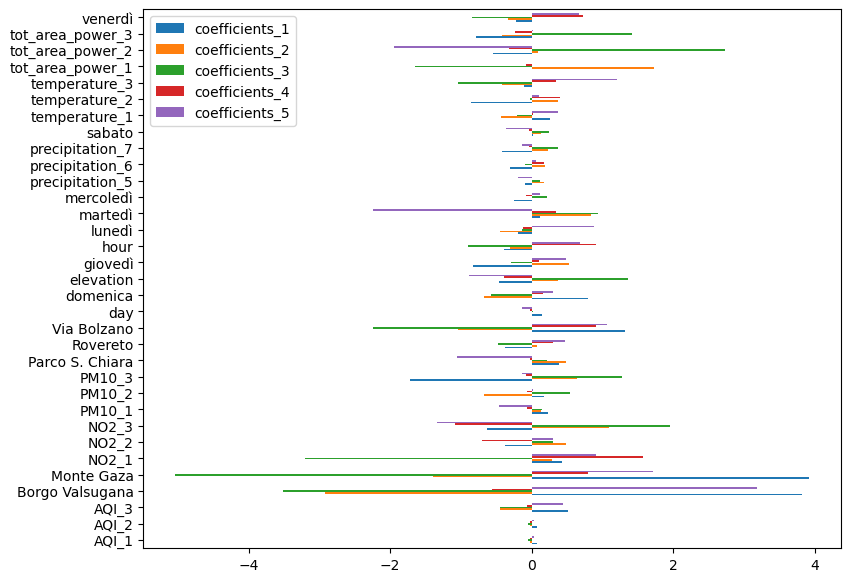

In [148]:
df_coef = pd.DataFrame(logreg.coef_.T,columns=['coefficients_1', 'coefficients_2', 'coefficients_3', 'coefficients_4', 'coefficients_5'],index=classification_features)
df_coef.plot.barh(figsize=(9,7))

In [157]:
y_pred = logreg.predict(scaled_test)
conf_mat  = confusion_matrix(test['target'], y_pred)
ConfusionMatrixDisplay(conf_mat, display_labels=logreg.classes_)
plt.show()

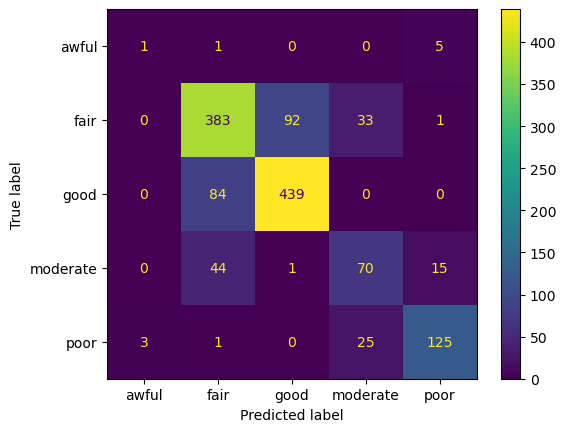

In [158]:
ConfusionMatrixDisplay.from_predictions(
    test['target'],
    y_pred,
    display_labels=logreg.classes_
)

plt.show()